# Morocco Electricity Consumption Analysis

In this Jupyter Notebook, we'll analyze electricity consumption in Morocco across 3 time zones in 10-minute intervals. I will try to uncover patterns in electricity consumption and assess which factors affect it the most.

The dataset is publicly available on [Maven Analytics](https://mavenanalytics.io/data-playground/morocco-electricity-consumption).

## Part 1: Importing the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'
%load_ext sql
%matplotlib inline

In [ ]:
df_dict = pd.read_csv('powerconsumption_datadictionary.csv')
df_dict

,Field,Description
0,Datetime,The date and time of the recording
1,Temperature,The Temperature in Celsius
2,Humidity,The concentration of water vapor in the air
3,WindSpeed,The speed of the wind in kilometers per hour
4,GeneralDiffuseFlows,The measurement of how much emissions gases di...
5,DiffuseFlows,The measurement of how much emissions gases di...
6,PowerConsumption_Zone1,The power consumption in Kilowatt-Hours in Pow...
7,PowerConsumption_Zone2,The power consumption in Kilowatt-Hours in Pow...
8,PowerConsumption_Zone3,The power consumption in Kilowatt-Hours in Pow...


In [ ]:
df = pd.read_csv('powerconsumption.csv')
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


## Part 2: Data Wrangling

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [ ]:
df.describe()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099


In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                52416 non-null  datetime64[ns]
 1   temperature             52416 non-null  float64       
 2   humidity                52416 non-null  float64       
 3   windspeed               52416 non-null  float64       
 4   generaldiffuseflows     52416 non-null  float64       
 5   diffuseflows            52416 non-null  float64       
 6   powerconsumption_zone1  52416 non-null  float64       
 7   powerconsumption_zone2  52416 non-null  float64       
 8   powerconsumption_zone3  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


Aside from data type conversion, there are no other necessary steps to clean this dataset, as it has no null values or sharp outliers. We can move on to the data analysis process.

## Part 3: Exploratory Data Analysis

We'll try to following questions during this analysis:
- At what points in time is electricity consumption in Morocco the highest?
- Which factors correlate with electricity consumption?
- What can be done to optimize power usage?

Text(0.5, 1.0, 'Correlation Between Environmental Factors and Elecricity Usage in Morocco')

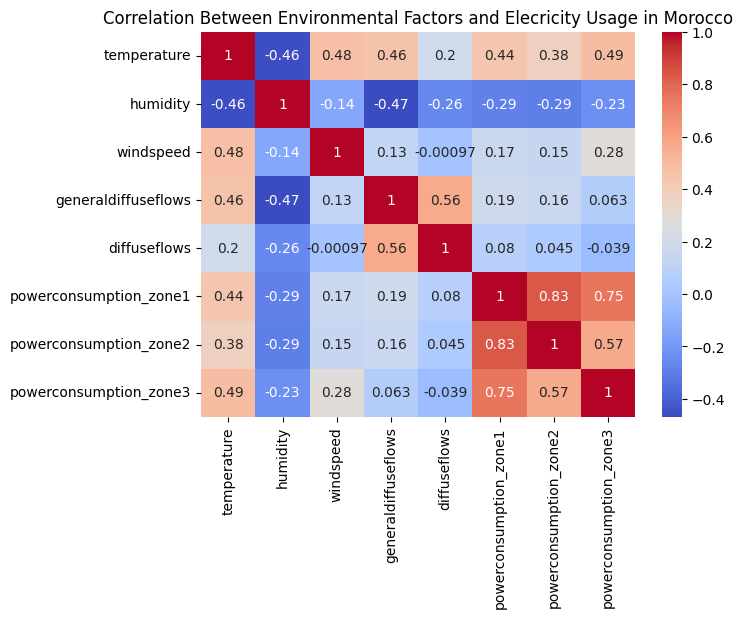

In [ ]:
nums = df.select_dtypes(include='float64')
fig = plt.figure(figsize = (7,5))
sns.heatmap(nums.corr(), annot=True, cmap = 'coolwarm')
plt.title('Correlation Between Environmental Factors and Elecricity Usage in Morocco')

We can derive a couple of interesting observations from this heatmap:

1.   Power consumption in the three zones is highly correlated, though the correlation is weaker between zones 2 and 3 at around 0.57.
2.   Humidity negatively correlates with all other factors at a medium level.
3.   Temperature has a medium correlation with all power consumption in all three zones, although the correlation is weaker in zone 2.
4.   Wind speed is correlated with power consumption in all three areas, though it is relatively insignificant (except for Zone 3 with the coefficient 0.28).

It's important to understand that correlation here is not causation. It is just that, in most cases, power consumption tends to be lower when humidity is high, or tends to be higher when temperature is higher. The pattern is true, but it is not a rule, and thus does not guarentee constant similar results.




Text(0.5, 1.0, 'The Relationship Between Temperature & Power Consumption in Zone 3')

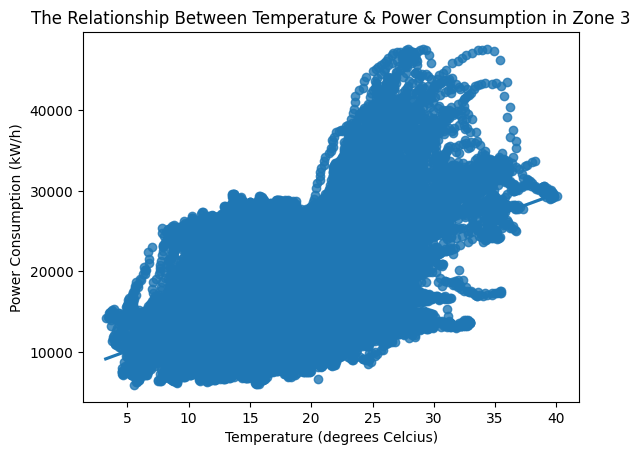

In [ ]:
sns.regplot(x='temperature', y='powerconsumption_zone3', data=df)
plt.xlabel('Temperature (degrees Celcius)')
plt.ylabel('Power Consumption (kW/h)')
plt.title('The Relationship Between Temperature & Power Consumption in Zone 3')

As we can see, the general pattern is present, but it does not guarantee perfect linear prediction.

Additionally, we can observe another interesting detail: after the temperature reaches around 20 degrees Celcius, power consumption significantly spikes in some time periods.

In [ ]:
con = sqlite3.connect('morocco_power_consumption.db')
%sql sqlite:///morocco_power_consumption.db
df.to_sql('power_consumption', con, index=False, if_exists='replace')

52416

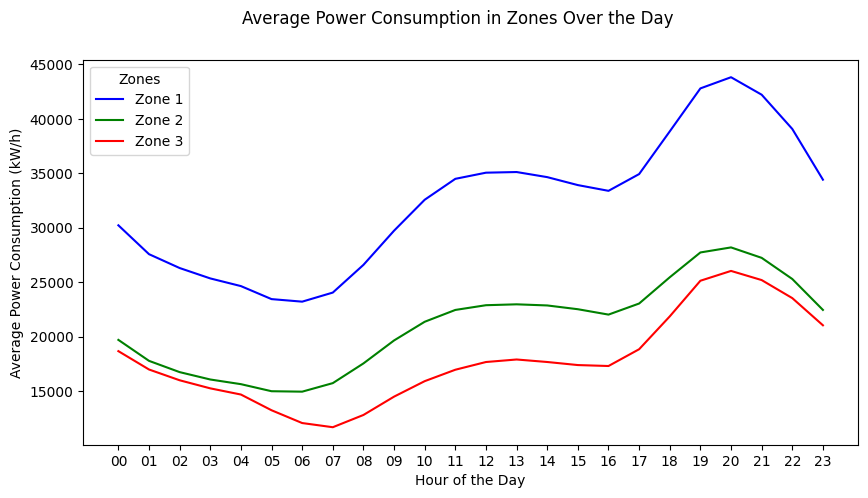

In [ ]:
query = """
SELECT
  strftime('%H', datetime) AS hour,
  ROUND(AVG(powerconsumption_zone1), 2) AS avg_power_consumption_1,
  ROUND(AVG(powerconsumption_zone2), 2) AS avg_power_consumption_2,
  ROUND(AVG(powerconsumption_zone3), 2) AS avg_power_consumption_3
FROM power_consumption
GROUP BY hour
ORDER BY hour
"""
query_res = pd.read_sql(query, con)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x='hour', y='avg_power_consumption_1', data = query_res, label = 'Zone 1', color = 'blue', ax = axs)
sns.lineplot(x='hour', y='avg_power_consumption_2', data = query_res, label = 'Zone 2', color = 'green', ax = axs)
sns.lineplot(x='hour', y='avg_power_consumption_3', data = query_res, label = 'Zone 3', color = 'red', ax = axs)
plt.xlabel('Hour of the Day')
plt.ylabel('Average Power Consumption (kW/h)')
plt.suptitle('Average Power Consumption in Zones Over the Day')
axs.legend(title = 'Zones', loc='upper left')

As we can see, even though the three zones have different consumption rates in absolute terms, they clearly share a pattern in how their power usage changes throughout the day.

- Power consumption in all three zones reaches its bottom between 5 and 7 AM.
- It then increases until 11 AM, reaching a plateau that lasts until 4 PM.
- After 5 PM, when people come back home, power consumption rises sharply, reaching the peak at around 8 PM.
- After the peak, power consumption rapidly declines as most residents go to sleep.

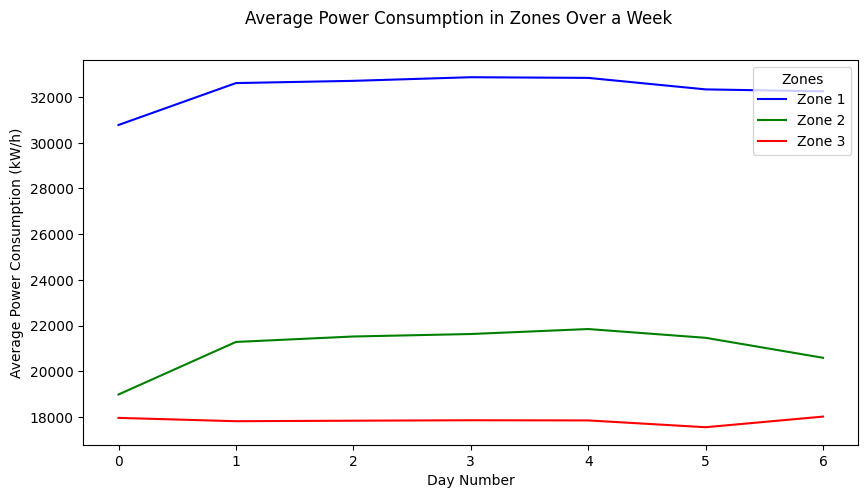

In [ ]:
query = """
SELECT
  strftime('%w', datetime) AS day,
  ROUND(AVG(powerconsumption_zone1), 2) AS avg_power_consumption_1,
  ROUND(AVG(powerconsumption_zone2), 2) AS avg_power_consumption_2,
  ROUND(AVG(powerconsumption_zone3), 2) AS avg_power_consumption_3
FROM power_consumption
GROUP BY day
ORDER BY day
"""
query_res = pd.read_sql(query, con)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x='day', y='avg_power_consumption_1', data = query_res, label = 'Zone 1', color = 'blue', ax = axs)
sns.lineplot(x='day', y='avg_power_consumption_2', data = query_res, label = 'Zone 2', color = 'green', ax = axs)
sns.lineplot(x='day', y='avg_power_consumption_3', data = query_res, label = 'Zone 3', color = 'red', ax = axs)
plt.xlabel('Day Number')
plt.ylabel('Average Power Consumption (kW/h)')
plt.suptitle('Average Power Consumption in Zones Over a Week')
axs.legend(title = 'Zones', loc='upper right')

There are no particularly useful insights when observing power usage on a weekly level.

It is notable, however, that power consumption was at its lowest on Monday in Zones 1 and 2. Moreover, on average, power consumption was slightly higher than average on Sunday in Zone 3 compared to other weekdays.

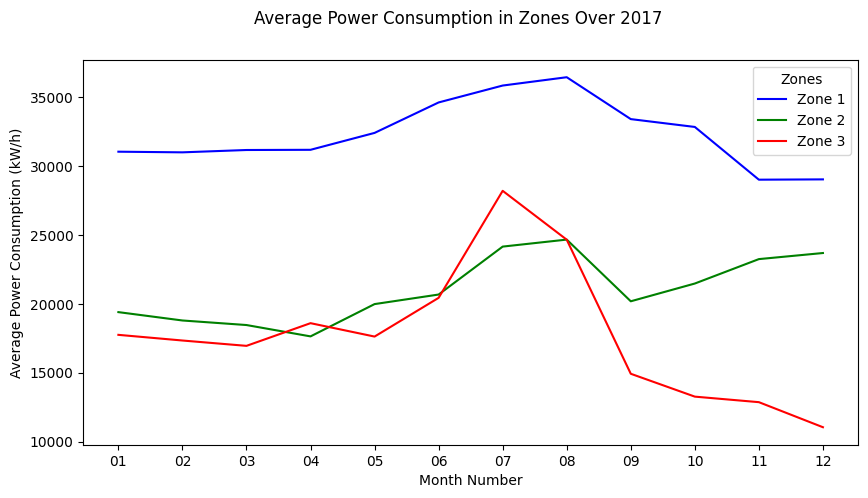

In [ ]:
query = """
SELECT
  strftime('%m', datetime) AS month,
  ROUND(AVG(powerconsumption_zone1), 2) AS avg_power_consumption_1,
  ROUND(AVG(powerconsumption_zone2), 2) AS avg_power_consumption_2,
  ROUND(AVG(powerconsumption_zone3), 2) AS avg_power_consumption_3
FROM power_consumption
GROUP BY month
ORDER BY month
"""
query_res = pd.read_sql(query, con)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x='month', y='avg_power_consumption_1', data = query_res, label = 'Zone 1', color = 'blue', ax = axs)
sns.lineplot(x='month', y='avg_power_consumption_2', data = query_res, label = 'Zone 2', color = 'green', ax = axs)
sns.lineplot(x='month', y='avg_power_consumption_3', data = query_res, label = 'Zone 3', color = 'red', ax = axs)
plt.xlabel('Month Number')
plt.ylabel('Average Power Consumption (kW/h)')
plt.suptitle('Average Power Consumption in Zones Over 2017')
axs.legend(title = 'Zones', loc='upper right')

This is another series of interesting patterns:
- Although all three zones experienced an increase in power consumption from May to August, electricity usage in Zones 1 and 3 has fallen, while Zone 2 experienced a decline in September before slowly climbing again.
- Zone 3 had the least stable monthly power consumption: it had spiked sharply in July, then rapidly declined to around 11000 kW/h in December.
  - Meanwhile, while the other 2 zones experienced a decline in September, their monthly power consumption rates remained relatively stable, with Zone 1 experiencing a relative decline to a level lower than January 2017 at the end of the year.

## Conclusion

**After conducting the data analysis, we've found multiple interesting insights:**
- Humidity has a reverse relationship with all other variables in the dataset, including power consumption in the three zones.
- Temperature and windspeed positively correlate with power consumption, though the relationship with temperature is stronger, with an average of around 0.42 for three zones.
- After the temperature reaches around 20 degrees Celcius, power consumption is more likely to rise sharply.
- In all three zones, power consumption reaches its bottom between 5-7 AM and reaches its peak at 8 PM.
- There are no significant fluctuations in power consumption on a weekly level.
- On an annual level, however, multiple differences come to mind:
  - Electricity usage in Zone 1 slowly climbed until August, then fell to levels below January at the end of the year.
  - Zone 2 experienced a similar climb until August, but recovered and roze again after a fall in September.
  - Zone 3 had the least stable trajectory of all: its power consumption rose sharply until July, then rapidly fell to 11000 kW/h in December - the lowest average monthly rate of all three zones.